## Import packages

Note that `rasterio` and `geopandas` need to be installed in the current Python environment for this notebook to work.

In [1]:
import cv2
from keras.utils import load_img
from keras.saving import load_model
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from skimage.measure import regionprops, regionprops_table
from tqdm import trange, tqdm

import segmenteverygrain as seg
import segmenteverygrain.interactions as si

%matplotlib qt

## Load models

In [2]:
# UNET model
unet = load_model(
    "../models/seg_model_smooth_labels.keras",
    custom_objects={"weighted_crossentropy": seg.weighted_crossentropy},
)

# Auto-detect device: CUDA for NVIDIA, MPS for Apple Silicon, CPU as fallback
import torch
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

# SAM 2.1 checkpoints. Download from:
# https://huggingface.co/facebook/sam2.1-hiera-large/resolve/main/sam2.1_hiera_large.pt
sam = build_sam2("configs/sam2.1/sam2.1_hiera_l.yaml", "../models/sam2.1_hiera_large.pt", device=device)

2026-08-13 14:37:09.614337: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2026-08-13 14:37:09.614368: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 96.00 GB
2026-08-13 14:37:09.614380: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 38.88 GB
I0000 00:00:1786649829.614395 135541721 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1786649829.614416 135541721 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## Run segmentation

Grains are supposed to be well defined in the image; e.g., if a grain consists of only a few pixels, it is unlikely to be detected.

The segmentation can take a few minutes even for medium-sized images, so do not start with large images (downsample them if necessary). Images with ~2000 pixels along their largest dimension are a good start.

In [3]:
fname = "../examples/RI_T01_Grid_65/RI_T01_Grid_65.tif"
image = np.array(load_img(fname))
image_pred = seg.predict_image(image, unet, I=256)

# decreasing the 'dbs_max_dist' parameter results in more SAM prompts
# (and longer processing times):
labels, coords = seg.label_grains(image, image_pred, dbs_max_dist=10.0)

# SAM segmentation, using the point prompts from the Unet:
all_grains, labels, mask_all, grain_data, fig, ax = seg.sam_segmentation(
    sam,
    image,
    image_pred,
    coords,
    labels,
    min_area=50.0,
    plot_image=True,
    remove_edge_grains=False,
    remove_large_objects=False,
)

segmenting image tiles...


100%|██████████| 5/5 [00:01<00:00,  3.55it/s]


creating masks using SAM...


100%|██████████| 1194/1194 [00:32<00:00, 37.13it/s]


finding overlapping polygons...


1192it [00:01, 846.63it/s] 


finding best polygons...


100%|██████████| 370/370 [00:03<00:00, 99.77it/s] 


creating labeled image...


100%|██████████| 413/413 [00:01<00:00, 342.78it/s]


## Interactive editing of segmentation results

Convert the polygons to Grain objects and use the interactive `GrainPlot` interface:

**Mouse controls:**
- **Left-click** on existing grain: Select/unselect
- **Left-click** in grain-free area: Instant grain creation
- **Alt + Left-click**: Multi-prompt grain creation
- **Alt + Right-click**: Background prompt for multi-prompt creation
- **Ctrl** (hold): Temporarily hide grain masks

**Keyboard controls:**
- **d**: Delete selected grains
- **m**: Merge selected grains
- **z**: Undo last created grain
- **Esc**: Clear selection and prompts

In [4]:
# Convert polygons to Grain objects
grains = si.polygons_to_grains(all_grains, image=image)
for g in tqdm(grains, desc='Measuring grains'):
    g.measure()

# Set up SAM 2.1 predictor for adding new grains
predictor = SAM2ImagePredictor(sam)
predictor.set_image(image)

# Create interactive plot
plot = si.GrainPlot(
    grains,
    image=image,
    predictor=predictor,
    blit=True,
    color_palette='Paired',
    figsize=(15, 10),
)
plot.activate()

Measuring and drawing grains: 100%|██████████| 413/413 [00:01<00:00, 366.44it/s]


Run this cell when you are done with interactive editing to retrieve the updated grains and deactivate the interface:

In [5]:
# Retrieve updated grains and deactivate interactive mode
grains = plot.get_grains()
plot.deactivate()

# Convert Grain objects back to shapely polygons for georeferencing
all_grains = [g.polygon for g in grains]

# Recreate labels from the updated grains
labels, mask_all = seg.create_labeled_image(all_grains, image)

Optionally, plot the updated set of grains with axes:

In [6]:
# Draw major and minor axes on each grain
plot.draw_axes()

## Save mask and image to PNG files

In [ ]:
dirname = "../examples/RI_T01_Grid_65/"
# write grayscale mask to PNG file
cv2.imwrite(dirname + fname.split("/")[-1][:-4] + "_mask.png", mask_all)
# Save the image as a PNG file
cv2.imwrite(
    dirname + fname.split("/")[-1][:-4] + "_image.png",
    cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
)

## Convert polygon row, col coordinates to projected coordinates and save them to shapefile

In [7]:
import rasterio
dataset = rasterio.open(fname)

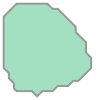

In [8]:
all_grains[0]

In [9]:
# convert polygon coordinates from row, col to UTM
from shapely.geometry import Polygon

projected_polys = []
for grain in all_grains:
    x, y = rasterio.transform.xy(
        dataset.transform, grain.exterior.xy[1], grain.exterior.xy[0]
    )
    poly = Polygon(np.vstack((x, y)).T)
    projected_polys.append(poly)

In [10]:
# create geopandas dataframe
import geopandas

gdf = geopandas.GeoDataFrame(projected_polys, columns=["geometry"])
gdf.head()

,geometry
0,"POLYGON ((339042.69 4686358.778, 339042.688 46..."
1,"POLYGON ((339041.993 4686358.592, 339041.992 4..."
2,"POLYGON ((339043.916 4686358.457, 339043.914 4..."
3,"POLYGON ((339043.831 4686358.481, 339043.829 4..."
4,"POLYGON ((339043.628 4686358.263, 339043.626 4..."


In [11]:
# create property dataframe from labeled image
props = regionprops_table(
    labels.astype("int"),
    intensity_image=image,
    properties=("label", "area", "centroid", "major_axis_length", "minor_axis_length"),
)
grain_data = pd.DataFrame(props)
grain_data["major_axis_length"] = grain_data["major_axis_length"].values
grain_data["minor_axis_length"] = grain_data["minor_axis_length"].values
grain_data["area"] = grain_data["area"].values
grain_data.head()

,label,area,centroid-0,centroid-1,major_axis_length,minor_axis_length
0,1,233.0,26.695279,415.042918,18.660877,16.195926
1,2,281.0,127.096085,31.587189,25.901750,14.120633
2,3,1480.0,190.110135,1082.204054,61.799613,32.319377
3,4,706.0,188.427762,1040.685552,35.160923,26.275374
4,5,1121.0,296.177520,942.931311,61.182857,27.898500


In [12]:
# convert centroids from row, col to UTM and add them to geodataframe
centroid_x, centroid_y = rasterio.transform.xy(
    dataset.transform, grain_data["centroid-0"], grain_data["centroid-1"]
)
gdf["centroid_x"] = centroid_x
gdf["centroid_y"] = centroid_y

In [15]:
# convert grain axis lengths and areas to UTM units
gdf["major_axis_length"] = grain_data["major_axis_length"] * dataset.transform[0]
gdf["minor_axis_length"] = grain_data["minor_axis_length"] * dataset.transform[0]
gdf["area"] = grain_data["area"] * dataset.transform[0] ** 2
gdf.head()

,geometry,centroid_x,centroid_y,major_axis_length,minor_axis_length,area
0,"POLYGON ((339042.69 4686358.778, 339042.688 46...",339042.688371,4.686359e+06,0.033590,0.029153,0.000755
1,"POLYGON ((339041.993 4686358.592, 339041.992 4...",339041.998150,4.686359e+06,0.046623,0.025417,0.000910
2,"POLYGON ((339043.916 4686358.457, 339043.914 4...",339043.889261,4.686358e+06,0.111239,0.058175,0.004795
3,"POLYGON ((339043.831 4686358.481, 339043.829 4...",339043.814527,4.686359e+06,0.063290,0.047296,0.002287
4,"POLYGON ((339043.628 4686358.263, 339043.626 4...",339043.638570,4.686358e+06,0.110129,0.050217,0.003632


In [ ]:
# plot grain size distribution
# units need to be in mm!

# no weighting
fig, ax = seg.plot_histogram_of_axis_lengths(
    gdf["major_axis_length"] * 1000,
    gdf["minor_axis_length"] * 1000,
    binsize=0.25,
    xlimits=[8, 2 * 256],
)

# area weighted
fig, ax = seg.plot_histogram_of_axis_lengths(
    gdf["major_axis_length"] * 1000,
    gdf["minor_axis_length"] * 1000,
    area=gdf["area"] * 1e6,   # m^2 to mm^2
    binsize=0.25,
    xlimits=[8, 2 * 256],
)

In [17]:
# check if everything looks good
band1 = dataset.read(1)
band2 = dataset.read(2)
band3 = dataset.read(3)
plt.figure()
plt.imshow(
    np.stack((band1, band2, band3), axis=2),
    extent=[dataset.bounds[0], dataset.bounds[2], dataset.bounds[1], dataset.bounds[3]],
)
plt.scatter(gdf["centroid_x"], gdf["centroid_y"]);

In [18]:
# set geodataframe CRS
gdf.crs = dataset.crs

In [ ]:
# write shapefile
gdf.to_file("../examples/RI_T01_Grid_65/projected_grains.shp")

In [19]:
dataset.close()